# Deep Learning mas sencillo(CNN)

In [2]:
%cd ..

c:\Users\juanw\Desktop\garbage-classification


In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.carga import cargar_datos
import cv2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,accuracy_score
import os

## Carga de los datos

In [5]:
root = 'data/Garbage-classification/Garbage-classification/'
df = cargar_datos(root)
df.head()

,x,y
443,data/Garbage-classification/Garbage-classifica...,glass
350,data/Garbage-classification/Garbage-classifica...,cardboard
2040,data/Garbage-classification/Garbage-classifica...,plastic
739,data/Garbage-classification/Garbage-classifica...,glass
288,data/Garbage-classification/Garbage-classifica...,cardboard


## Carga de Datos desde Colab


In [ ]:
import kagglehub

# Descargar dataset
path = kagglehub.dataset_download("asdasdasasdas/garbage-classification", path="data/")

print(f"📦 Dataset descargado en: {path}")

## Division de los datos

In [6]:
from sklearn.model_selection import train_test_split

# 80% train, 20% (test + validación)
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['y']
 )

# Del 20% (test + validacion): 10% validación y 10% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['y']
 )

print(f"Train: {len(train_df)} ({len(train_df)/len(df):.1%})")
print(f"Validación: {len(val_df)} ({len(val_df)/len(df):.1%})")
print(f"Test: {len(test_df)} ({len(test_df)/len(df):.1%})")

Train: 2021 (80.0%)
Validación: 253 (10.0%)
Test: 253 (10.0%)


## Modificacion de las imagenes y carga en memoria.

Al aplicar modelos lineales los cuales no tienen como argumento el batch_size tenemos que hacer la carga de todas las imagenes en memoria y transformarlas a un vector unico por imagen para poder darselas al modelo.

In [7]:
def load_images(df, size):
    images = []
    labels = []
    
    for _, row in df.iterrows():
        ruta = row['x']
        label = row['y']
        
        img = cv2.imread(ruta)                  
        img = cv2.resize(img, (size, size))    
        img = img.astype('float32') / 255.0    
        
        images.append(img)
        labels.append(label)
    
    X = np.array(images)
    y = np.array(labels)
    
    return X, y

In [8]:
x_train, y_train = load_images(train_df, size=128)
x_val, y_val = load_images(val_df, size=128)
x_test, y_test = load_images(test_df, size=128)

In [9]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((2021, 128, 128, 3),
 (2021,),
 (253, 128, 128, 3),
 (253,),
 (253, 128, 128, 3),
 (253,))

Encoding para los lebels

In [11]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val  = le.transform(y_val)
y_test  = le.transform(y_test)

In [12]:
le.classes_

array(['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'],
      dtype='<U9')

## Aplicacion modelo 

In [33]:
from src.modelo_simple import estructura_modelo,compilar
from src.curvas import graf_pedida,graf_acc

In [34]:
modelo3,resumen=estructura_modelo(input_shape=(128, 128, 3), num_classes=len(le.classes_))
print(resumen)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 6)    │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 6)              │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210 (840.00 B)

 Trainable params: 210 (840.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [35]:
modelo3=compilar(modelo3,learning_rate=0.001)

In [36]:
hist = modelo3.fit(x_train,y_train,validation_data=(x_val, y_val),batch_size=128,epochs=200)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - loss: 1.8744 - sparse_categorical_accuracy: 0.0544 - val_loss: 1.8177 - val_sparse_categorical_accuracy: 0.0553
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.7990 - sparse_categorical_accuracy: 0.1460 - val_loss: 1.7809 - val_sparse_categorical_accuracy: 0.1976
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.7642 - sparse_categorical_accuracy: 0.2128 - val_loss: 1.7503 - val_sparse_categorical_accuracy: 0.2372
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.7424 - sparse_categorical_accuracy: 0.2350 - val_loss: 1.7355 - val_sparse_categorical_accuracy: 0.2372
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 1.7299 - sparse_categorical_accuracy: 0.2350 - val_loss: 1.7261 - val_sparse_categorical_accuracy: 0.2372
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 1.7225 - sparse_categorical_accuracy: 0.2350 - val_loss: 1.7195 - val_sparse_categorical_accuracy: 0.2372
Epoc

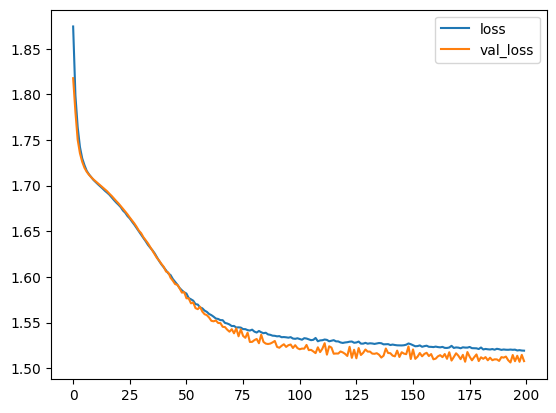

None


In [37]:
grafico = graf_pedida(hist)
print(grafico)

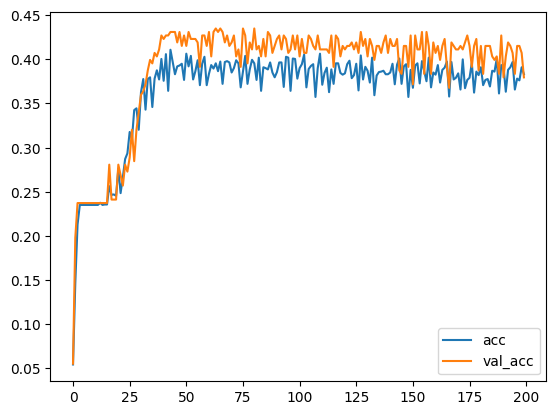

None


In [38]:
grafico2 = graf_acc(hist)
print(grafico2)

### Evaluamos el modelo 

In [39]:
score1 = modelo3.evaluate(x_train, y_train, steps=100)
print(score1)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5184 - sparse_categorical_accuracy: 0.3681
[1.518371820449829, 0.36813458800315857]


In [40]:
score2 = modelo3.evaluate(x_val, y_val, steps=100)
print(score2)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5077 - sparse_categorical_accuracy: 0.3794   
[1.5077189207077026, 0.3794466257095337]


In [ ]:
score3 = modelo3.evaluate(x_test, y_test, steps=100)
print(score3)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.5626 - sparse_categorical_accuracy: 0.3755
[1.5626448392868042, 0.3754940629005432]


### Matrices de confusion

In [42]:
y_train_pred3 = modelo3.predict(x_train)
y_train_pred3 = y_train_pred3.argmax(axis=1)


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [43]:
y_val_pred3 = modelo3.predict(x_val)
y_val_pred3 = y_val_pred3.argmax(axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [44]:
y_test_pred3 = modelo3.predict(x_test)
y_test_pred3 = y_test_pred3.argmax(axis=1)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


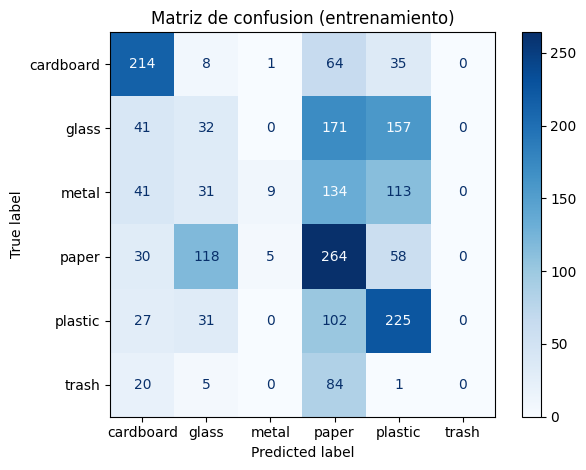

In [45]:
plot_confusion(y_train, y_train_pred3, le.classes_, title='Matriz de confusion (entrenamiento)')

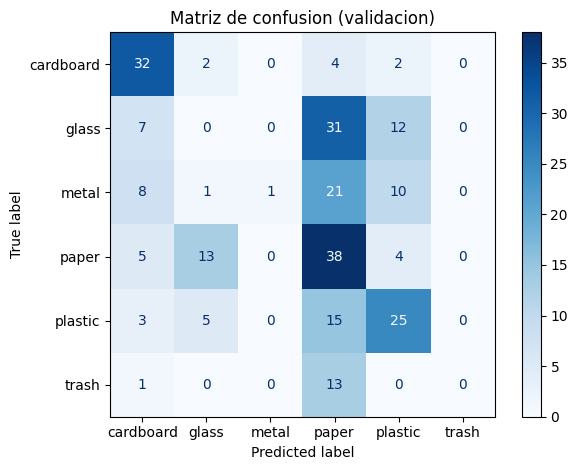

In [46]:
plot_confusion(y_val, y_val_pred3, le.classes_, title='Matriz de confusion (validacion)')

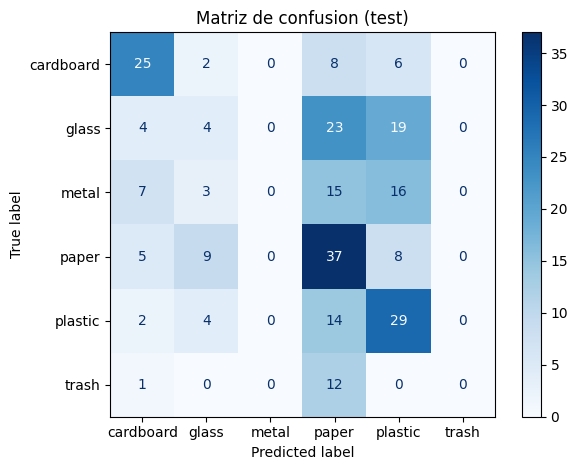

In [47]:
plot_confusion(y_test, y_test_pred3, le.classes_, title='Matriz de confusion (test)')

### Mas metricas

In [48]:
print("Classification Report - Train:")
print(classification_report(y_train, y_train_pred3, target_names=le.classes_))

Classification Report - Train:
              precision    recall  f1-score   support

   cardboard       0.57      0.66      0.62       322
       glass       0.14      0.08      0.10       401
       metal       0.60      0.03      0.05       328
       paper       0.32      0.56      0.41       475
     plastic       0.38      0.58      0.46       385
       trash       0.00      0.00      0.00       110

    accuracy                           0.37      2021
   macro avg       0.34      0.32      0.27      2021
weighted avg       0.37      0.37      0.31      2021



In [49]:
print("Classification Report - validacion:")
print(classification_report(y_val, y_val_pred3, target_names=le.classes_))

Classification Report - validacion:
              precision    recall  f1-score   support

   cardboard       0.57      0.80      0.67        40
       glass       0.00      0.00      0.00        50
       metal       1.00      0.02      0.05        41
       paper       0.31      0.63      0.42        60
     plastic       0.47      0.52      0.50        48
       trash       0.00      0.00      0.00        14

    accuracy                           0.38       253
   macro avg       0.39      0.33      0.27       253
weighted avg       0.42      0.38      0.31       253



In [50]:
print("Classification Report - test:")
print(classification_report(y_test, y_test_pred3, target_names=le.classes_))

Classification Report - test:
              precision    recall  f1-score   support

   cardboard       0.57      0.61      0.59        41
       glass       0.18      0.08      0.11        50
       metal       0.00      0.00      0.00        41
       paper       0.34      0.63      0.44        59
     plastic       0.37      0.59      0.46        49
       trash       0.00      0.00      0.00        13

    accuracy                           0.38       253
   macro avg       0.24      0.32      0.27       253
weighted avg       0.28      0.38      0.31       253

